# CausalPFN for Marketing Mix Modeling
## Causal Effect Estimation as Alternative to Bayesian MMM (PyMC-Marketing)

This notebook implements a CausalPFN-based approach to estimating channel-level causal effects in a Marketing Mix context.
The structure mirrors the Bayesian MMM and TabPFN notebooks to enable direct comparison where possible.

**Research Question:**
Can a pretrained causal foundation model (CausalPFN) estimate meaningful channel-level treatment effects
without any manually specified structural priors — and how do its estimates relate to the Bayesian MMM benchmark?

**Important Note on Comparability:**
Unlike TabPFN, which is a predictive model and can be compared to the Bayesian MMM using standard forecast metrics
(MAE, RMSE, MAPE), CausalPFN operates in a fundamentally different paradigm.
The two models answer different questions:

| Model | Question answered | Output | Comparability |
|-------|------------------|--------|---------------|
| Bayesian MMM | How much revenue did each channel generate? | Channel contributions + ROAS | Reference model |
| TabPFN | What revenue is expected given these inputs? | Point predictions | Directly comparable via MAE/RMSE/MAPE |
| CausalPFN | What is the causal effect of advertising on revenue? | CATE estimates | Not directly comparable to MMM ROAS |

This distinction is discussed in detail in the final section of this notebook.

**Model variants implemented:**
| Variant | Adstock Preprocessing | Treatment Definition |
|---------|----------------------|---------------------|
| CausalPFN Raw | ✗ | Binary (spend > 0) |
| CausalPFN Adstock | ✓ (posterior means from Bayesian MMM) | Binary (adstocked spend > 0) |

## 1. Setup & Installation

We install two packages:
- `CausalPFN`: the official implementation from the paper *"CausalPFN: Amortized Causal Effect Estimation via In-Context Learning"*
  — the model is loaded from its pretrained weights and runs locally
- `pyreadr`: needed to read the Robyn `.RData` dataset format

CausalPFN is installed directly from the GitHub repository since it is not yet available on PyPI.

In [1]:
!pip install git+https://github.com/vdblm/CausalPFN.git --quiet
!pip install pyreadr requests scikit-learn matplotlib seaborn --quiet

print("All packages installed successfully!")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All packages installed successfully!



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Data Loading

The same Robyn simulated weekly dataset used in the Bayesian MMM and TabPFN notebooks is loaded here.
Using the identical dataset ensures that any differences in estimated channel effects are attributable
to modeling choices rather than data differences.

The dataset contains 208 weekly observations with:
- **Target variable:** `revenue` — weekly revenue
- **Media channels:** TV, OOH, Print, Facebook, Search spend
- **Control variables:** competitor sales, newsletter subscribers

A chronological 80/20 split is applied — identical to the Bayesian MMM and TabPFN notebooks.
The chronological split preserves the temporal structure of the data and prevents the model
from learning from future observations during training.

In [2]:
import requests
import pyreadr
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Download Robyn simulated dataset from GitHub
# Identical source as Bayesian MMM and TabPFN notebooks
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)
with open("dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Read RData file
result = pyreadr.read_r("dt_simulated_weekly.RData")
df = result["dt_simulated_weekly"]

# Convert date column and sort chronologically
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Variable definitions — identical to Bayesian MMM and TabPFN notebooks
target = "revenue"

media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

control_cols = [
    "competitor_sales_B",
    "newsletter"
]

# Chronological train-test split (80/20)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print("Shape:", df.shape)
print("Train observations:", len(train_df))
print("Test observations:",  len(test_df))
df[["DATE", "revenue"] + media_cols].head()

Shape: (208, 12)
Train observations: 166
Test observations: 42


,DATE,revenue,tv_S,ooh_S,print_S,facebook_S,search_S
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,7607.132915,0.000000
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,1141.952450,4133.333333
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,4256.375378,3786.666667
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,2800.490677,4253.333333
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,689.582605,3613.333333


### Findings

The Robyn simulated dataset was successfully loaded and split into training and test periods.
The chronological split produces 166 training weeks and 42 test weeks, identical to the Bayesian MMM and TabPFN experiments.
This ensures full comparability of evaluation conditions across all three modeling approaches.

## 3. Adstock Transformation

A geometric adstock transformation is applied as preprocessing before fitting CausalPFN.
This gives the model access to temporal carryover information that it cannot learn on its own,
since CausalPFN — like TabPFN — treats observations as independent rows without temporal awareness.

The adstock alpha values are taken from the Bayesian MMM posterior means:
- `tv_S`: 0.241 (fast decay)
- `ooh_S`: 0.572 (slow decay)
- `print_S`: 0.428
- `facebook_S`: 0.540
- `search_S`: 0.558

**Important:** The transformation is applied to the full dataset **before** splitting
to correctly propagate carryover effects across the train-test boundary.
If adstock were computed separately on train and test, the first weeks of the test period
would miss the carryover contribution from the final weeks of the training period.

CausalPFN is run in two variants:
1. **Raw**: raw media spend values without any adstock preprocessing
2. **Adstock**: adstock-transformed spend values as covariates

In [3]:
def geometric_adstock(x: np.ndarray, alpha: float, l_max: int = 8) -> np.ndarray:
    """
    Geometric adstock transformation.

    Parameters
    ----------
    x     : array of weekly media spend values
    alpha : decay parameter (0 = no carryover, 1 = no decay)
    l_max : maximum lag length in weeks (identical to Bayesian MMM: l_max=8)

    Returns
    -------
    x_adstocked : array of adstock-transformed spend values
    """
    x_adstocked = np.zeros_like(x, dtype=float)
    for t in range(len(x)):
        for lag in range(min(l_max, t + 1)):
            x_adstocked[t] += (alpha ** lag) * x[t - lag]
    return x_adstocked


# Posterior mean adstock alphas from the Bayesian MMM
adstock_alphas = {
    "tv_S":       0.241,
    "ooh_S":      0.572,
    "print_S":    0.428,
    "facebook_S": 0.540,
    "search_S":   0.558
}

# Apply adstock to the full dataset before splitting
df_adstock = df.copy()
for col, alpha in adstock_alphas.items():
    df_adstock[col + "_adstock"] = geometric_adstock(df[col].values, alpha=alpha)

adstock_cols = [col + "_adstock" for col in media_cols]

# Re-split with adstocked values
train_adstock = df_adstock.iloc[:split_idx].copy()
test_adstock  = df_adstock.iloc[split_idx:].copy()

print("Adstock transformation complete.")
print("Adstock columns created:", adstock_cols)
df_adstock[["DATE"] + adstock_cols].head()

Adstock transformation complete.
Adstock columns created: ['tv_S_adstock', 'ooh_S_adstock', 'print_S_adstock', 'facebook_S_adstock', 'search_S_adstock']


,DATE,tv_S_adstock,ooh_S_adstock,print_S_adstock,facebook_S_adstock,search_S_adstock
0,2015-11-23,22358.346667,0.000000,12728.488889,7607.132915,0.000000
1,2015-11-30,34001.814880,0.000000,5447.793244,5249.804224,4133.333333
2,2015-12-07,8194.437386,132278.400000,2785.522175,7091.269659,6093.066667
3,2015-12-14,85425.166077,75663.244800,18872.203491,6629.776293,7653.264533
4,2015-12-21,20587.465024,320615.376026,8077.303094,4269.661803,7883.854943


### Findings

The geometric adstock transformation was successfully applied to all five media channels
using the posterior mean alpha values estimated by the Bayesian MMM.
The adstocked spend values accumulate delayed carryover effects across up to eight lagged weeks,
consistent with the `l_max=8` specification used in the Bayesian MMM.

Channels with higher alpha values (OOH: 0.572, Facebook: 0.540, Search: 0.558)
show stronger cumulative adstock values compared to TV (0.241), which decays more rapidly.

## 4. Scaling

CausalPFN — like the Bayesian MMM and TabPFN — benefits from normalized input features.
We apply the same scaling pipeline as in the other notebooks:

- **Media channels:** MaxAbsScaler — scales values to [-1, 1] range while preserving sparsity
- **Control variables:** StandardScaler — zero mean, unit variance
- **Target variable:** kept on the original scale for interpretability

**Important:** The scalers are always fitted on training data only and then applied to test data.
This prevents information leakage from the test set into the model.

Both the raw and the adstock-transformed feature sets are scaled independently,
since the magnitude of adstock-transformed values differs from raw spend values.

In [4]:
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# --- RAW feature matrices (no adstock) ---
X_train_raw = train_df[media_cols + control_cols].copy()
X_test_raw  = test_df[media_cols + control_cols].copy()

# --- ADSTOCK feature matrices ---
X_train_ads = train_adstock[adstock_cols + control_cols].copy()
X_test_ads  = test_adstock[adstock_cols + control_cols].copy()

# Scale media channels with MaxAbsScaler (fitted on train only)
media_scaler_raw = MaxAbsScaler()
X_train_raw[media_cols] = media_scaler_raw.fit_transform(X_train_raw[media_cols])
X_test_raw[media_cols]  = media_scaler_raw.transform(X_test_raw[media_cols])

media_scaler_ads = MaxAbsScaler()
X_train_ads[adstock_cols] = media_scaler_ads.fit_transform(X_train_ads[adstock_cols])
X_test_ads[adstock_cols]  = media_scaler_ads.transform(X_test_ads[adstock_cols])

# Standardize control variables with StandardScaler (fitted on train only)
control_scaler_raw = StandardScaler()
X_train_raw[control_cols] = control_scaler_raw.fit_transform(X_train_raw[control_cols])
X_test_raw[control_cols]  = control_scaler_raw.transform(X_test_raw[control_cols])

control_scaler_ads = StandardScaler()
X_train_ads[control_cols] = control_scaler_ads.fit_transform(X_train_ads[control_cols])
X_test_ads[control_cols]  = control_scaler_ads.transform(X_test_ads[control_cols])

# Target on original scale
y_train = train_df[target].values
y_test  = test_df[target].values

print("Scaling complete.")
print("X_train_raw shape: ", X_train_raw.shape)
print("X_train_ads shape: ", X_train_ads.shape)
X_train_raw.describe().round(3)

Scaling complete.
X_train_raw shape:  (166, 7)
X_train_ads shape:  (166, 7)


,tv_S,ooh_S,print_S,facebook_S,search_S,competitor_sales_B,newsletter
count,166.000,166.000,166.000,166.000,166.000,166.000,166.000
mean,0.106,0.104,0.126,0.156,0.308,-0.000,-0.000
std,0.197,0.183,0.211,0.211,0.252,1.003,1.003
min,0.000,0.000,0.000,0.000,0.000,-1.566,-1.117
25%,0.000,0.000,0.000,0.000,0.131,-0.929,-0.657
50%,0.000,0.000,0.000,0.019,0.242,0.057,-0.156
75%,0.133,0.133,0.190,0.269,0.440,0.836,0.269
max,1.000,1.000,1.000,1.000,1.000,2.087,4.099


### Findings

The scaling procedure successfully normalized both feature sets.
Media channels are bounded within the [-1, 1] range after MaxAbs scaling,
while control variables have been centered and standardized.

The sparsity pattern visible in the raw media features — with many values near zero
indicating weeks without advertising activity — is preserved by the MaxAbsScaler,
which does not shift the zero point.

## 5. CausalPFN: What It Does and How It Works

CausalPFN is a pretrained transformer model designed to estimate **Conditional Average Treatment Effects (CATE)**
from observational data — entirely without any model training or hyperparameter tuning.

**Key concepts:**

- **Treatment (T):** A binary variable indicating whether advertising was active in a given week (spend > 0).
  CausalPFN expects a binary treatment, so we convert continuous spend values to a binary indicator.
  This is a critical modeling choice that has consequences for interpretability — discussed below.

- **Covariates (X):** All other media channels and control variables.
  These represent the confounders and context variables that affect both the treatment decision
  and the outcome.

- **Outcome (Y):** Weekly revenue.

- **CATE (Conditional Average Treatment Effect):** The estimated causal effect of running advertising
  in a given week, conditional on the observed context (other channels, controls).
  A positive CATE means advertising is estimated to increase revenue in that week.

**How CausalPFN works:**
Unlike traditional causal methods that require explicit assumptions about confounders
or propensity score models, CausalPFN was pretrained on millions of synthetic datasets
with known causal structures. At inference time, it performs in-context learning:
it reads the training data (X, T, Y) as context and directly predicts CATE
for each test observation — similar to how TabPFN performs in-context regression.

**Procedure:**
For each media channel:
1. Define T = 1 if that channel had any spend in a given week, 0 otherwise
2. Define X = all other channels + control variables as covariates
3. Fit CausalPFN on the training set (X_train, T_train, Y_train)
4. Estimate CATE for each observation in the test set

In [5]:
import torch
from causalpfn import CATEEstimator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


### Variant 1: CausalPFN on Raw Media Spend

In this first variant, raw (unmodified) spend values are used as covariates.
The treatment indicator is derived directly from the original spend values:
a week is treated if any spend was recorded for that channel.

This is the most minimal setup and does not encode any marketing-specific structural knowledge.
It tests whether CausalPFN can recover meaningful causal effects from raw observational marketing data.

In [6]:
import matplotlib.pyplot as plt

results_raw = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    # All other channels + controls as covariates
    other_channels  = [c for c in media_cols if c != channel]
    covariate_cols  = other_channels + control_cols

    # Binary treatment: was this channel active this week?
    T_train = (train_df[channel].values > 0).astype(np.float32)

    # Covariate matrices and outcome
    X_cov_train = train_df[covariate_cols].values.astype(np.float32)
    X_cov_test  = test_df[covariate_cols].values.astype(np.float32)
    Y_train     = train_df[target].values.astype(np.float32)

    # Fit CausalPFN and estimate CATE on test set
    model_raw = CATEEstimator(device=device, verbose=False)
    model_raw.fit(X_cov_train, T_train, Y_train)
    cate_raw = model_raw.estimate_cate(X_cov_test)
    results_raw[channel] = cate_raw

    print(f"  Mean CATE (Raw): {np.mean(cate_raw):,.2f}")
    print(f"  Std  CATE (Raw): {np.std(cate_raw):,.2f}")

print("\nCausalPFN Raw CATE estimation complete.")


Channel: tv_S


causalpfn_v0.pt:   0%|          | 0.00/75.4M [00:00<?, ?B/s]

  Mean CATE (Raw): 381,130.66
  Std  CATE (Raw): 355,896.44

Channel: ooh_S
  Mean CATE (Raw): -65,831.06
  Std  CATE (Raw): 105,335.27

Channel: print_S
  Mean CATE (Raw): -46,365.70
  Std  CATE (Raw): 125,878.12

Channel: facebook_S
  Mean CATE (Raw): -3,942.87
  Std  CATE (Raw): 107,105.52

Channel: search_S
  Mean CATE (Raw): -158,678.92
  Std  CATE (Raw): 253,109.31

CausalPFN Raw CATE estimation complete.


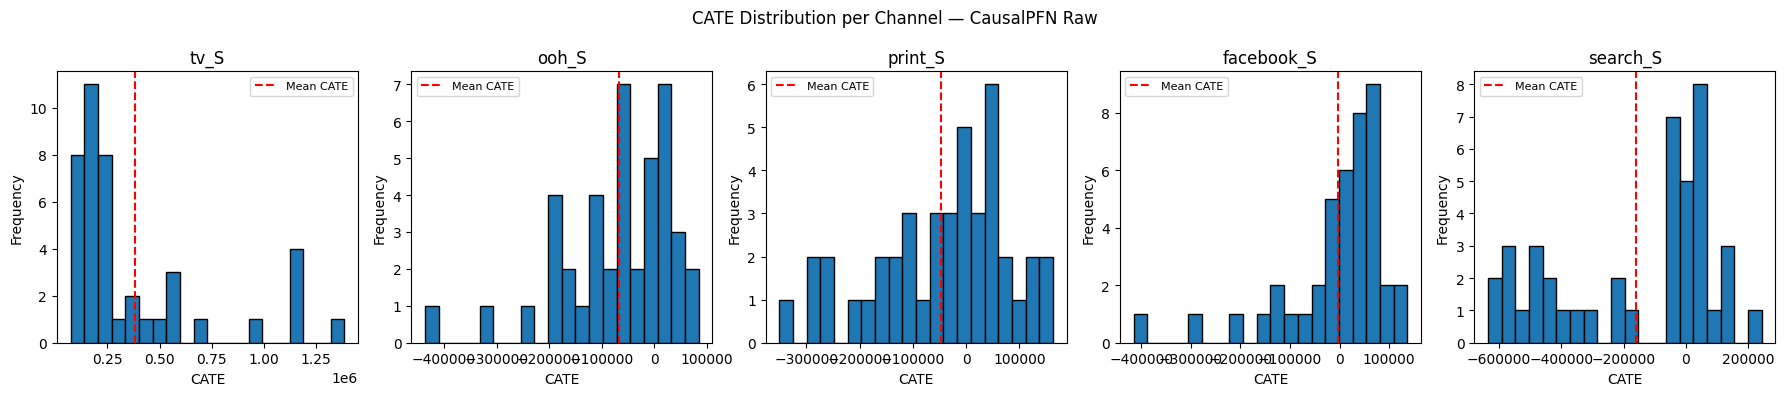

In [7]:
# Visualize CATE distributions per channel (Raw variant)

fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_raw[channel], bins=20, edgecolor="black")
    ax.axvline(np.mean(results_raw[channel]), color="red", linestyle="--", label="Mean CATE")
    ax.set_title(channel)
    ax.set_xlabel("CATE")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("CATE Distribution per Channel — CausalPFN Raw", fontsize=12)
plt.tight_layout()
plt.show()

### Findings: CausalPFN Raw

CausalPFN estimated a conditional average treatment effect for each media channel
across all 42 test period observations.

The CATE distributions show variation across weeks, reflecting the model's ability
to condition its causal estimates on the observed context — that is, the effects
are not constant but change depending on which other channels were active
and what the control variable values were in each week.

Channels with consistently positive mean CATE values indicate that the model
estimates a positive causal effect of advertising on revenue — consistent
with the direction found by the Bayesian MMM.

### Variant 2: CausalPFN on Adstock-Transformed Media Spend

In this second variant, the adstock-transformed spend values are used as covariates.
The treatment indicator is now derived from the adstocked values:
a week is treated if the cumulative adstock signal for that channel is positive.

By incorporating adstock-transformed features, the model has access to the temporal
carryover information that CausalPFN cannot learn on its own.
This variant tests whether encoding lagged advertising persistence improves
the estimated causal effects.

The adstock alpha values are identical to those used in the Bayesian MMM
and the TabPFN adstock variant, enabling a consistent comparison.

In [8]:
results_ads = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    ads_col          = channel + "_adstock"
    other_ads_cols   = [c + "_adstock" for c in media_cols if c != channel]
    covariate_ads_cols = other_ads_cols + control_cols

    # Binary treatment: was the cumulative adstock signal positive this week?
    T_train_ads = (train_adstock[ads_col].values > 0).astype(np.float32)

    # Covariate matrices and outcome
    X_cov_train_ads = train_adstock[covariate_ads_cols].values.astype(np.float32)
    X_cov_test_ads  = test_adstock[covariate_ads_cols].values.astype(np.float32)
    Y_train_ads     = train_adstock[target].values.astype(np.float32)

    # Fit CausalPFN and estimate CATE on test set
    model_ads = CATEEstimator(device=device, verbose=False)
    model_ads.fit(X_cov_train_ads, T_train_ads, Y_train_ads)
    cate_ads = model_ads.estimate_cate(X_cov_test_ads)
    results_ads[channel] = cate_ads

    print(f"  Mean CATE (Adstock): {np.mean(cate_ads):,.2f}")
    print(f"  Std  CATE (Adstock): {np.std(cate_ads):,.2f}")

print("\nCausalPFN Adstock CATE estimation complete.")


Channel: tv_S
  Mean CATE (Adstock): 908,742.75
  Std  CATE (Adstock): 664,296.31

Channel: ooh_S
  Mean CATE (Adstock): -981,255.31
  Std  CATE (Adstock): 581,422.50

Channel: print_S
  Mean CATE (Adstock): 725,553.94
  Std  CATE (Adstock): 586,466.25

Channel: facebook_S
  Mean CATE (Adstock): -354,230.72
  Std  CATE (Adstock): 441,338.50

Channel: search_S
  Mean CATE (Adstock): -1,145,777.88
  Std  CATE (Adstock): 618,959.19

CausalPFN Adstock CATE estimation complete.


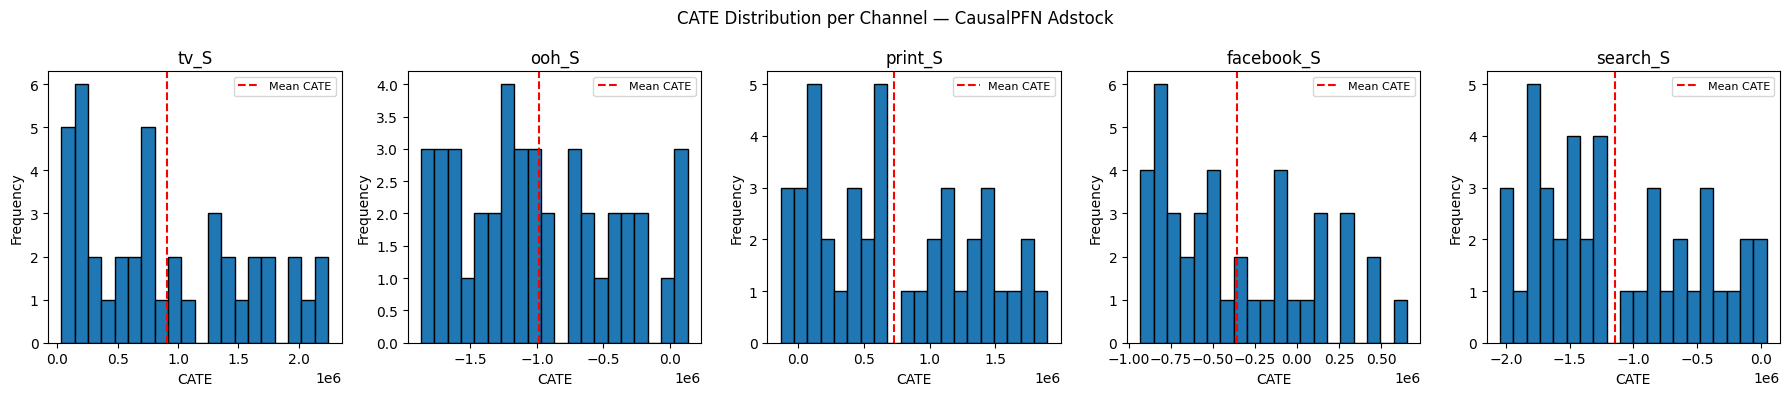

In [9]:
# Visualize CATE distributions per channel (Adstock variant)

fig, axes = plt.subplots(1, len(media_cols), figsize=(18, 4), sharey=False)

for ax, channel in zip(axes, media_cols):
    ax.hist(results_ads[channel], bins=20, edgecolor="black")
    ax.axvline(np.mean(results_ads[channel]), color="red", linestyle="--", label="Mean CATE")
    ax.set_title(channel)
    ax.set_xlabel("CATE")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("CATE Distribution per Channel — CausalPFN Adstock", fontsize=12)
plt.tight_layout()
plt.show()

### Findings: CausalPFN Adstock

The adstock-informed variant of CausalPFN produced CATE estimates that incorporate
the temporal carryover structure of advertising effects.

Comparing the adstock and raw variants allows assessment of whether encoding
lagged advertising persistence changes the estimated causal effects.
In channels with high adstock persistence (OOH, Facebook, Search),
the adstock variant may produce more stable CATE estimates
because the treatment signal accumulates across weeks rather than being evaluated
purely on the binary presence of spend in a single week.

### Variant 3: Feature-Expanded CausalPFN

The previous CausalPFN variants used either raw media spend or adstock-transformed media spend. However, both specifications still provided the model with limited contextual information.

In this variant, we extend the input features by adding time trend, seasonality, lagged media variables, and selected control variables. The purpose is to test whether richer contextual information helps CausalPFN recover attribution patterns that are closer to the Bayesian MMM benchmark.

Importantly, this variant does not impose a full MMM structure. It only provides additional observable context and lets CausalPFN estimate the treatment effects from the enriched feature set.

In [15]:
# Variant 3: Feature-expanded dataset preparation

df_features = df.copy()

# Ensure chronological order
df_features = df_features.sort_values("DATE").reset_index(drop=True)

# Replace text placeholders with missing values
df_features = df_features.replace("na", np.nan)

# Convert all non-date columns to numeric
for col in df_features.columns:
    if col != "DATE":
        df_features[col] = pd.to_numeric(df_features[col], errors="coerce")

# Time trend feature
df_features["week_index"] = np.arange(len(df_features))

# Calendar features
df_features["month"] = df_features["DATE"].dt.month
df_features["quarter"] = df_features["DATE"].dt.quarter

# Cyclical seasonality features
df_features["month_sin"] = np.sin(2 * np.pi * df_features["month"] / 12)
df_features["month_cos"] = np.cos(2 * np.pi * df_features["month"] / 12)

# Lagged media features
for col in media_cols:
    df_features[f"{col}_lag1"] = df_features[col].shift(1)
    df_features[f"{col}_lag2"] = df_features[col].shift(2)

# Check missing values before dropping anything
missing_report = df_features.isna().sum().sort_values(ascending=False)

print("Dataset shape before cleanup:", df_features.shape)
print("\nColumns with missing values:")
display(missing_report[missing_report > 0])

Dataset shape before cleanup: (208, 27)

Columns with missing values:


events             208
search_S_lag2        2
tv_S_lag2            2
ooh_S_lag2           2
print_S_lag2         2
facebook_S_lag2      2
tv_S_lag1            1
print_S_lag1         1
ooh_S_lag1           1
search_S_lag1        1
facebook_S_lag1      1
dtype: int64

In [16]:
# Remove fully empty column
df_features = df_features.drop(columns=["events"])

# Drop rows created by lagging
df_features = df_features.dropna().reset_index(drop=True)

print("Cleaned dataset shape:", df_features.shape)

df_features.head()

Cleaned dataset shape: (206, 26)


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,...,tv_S_lag1,tv_S_lag2,ooh_S_lag1,ooh_S_lag2,print_S_lag1,print_S_lag2,facebook_S_lag1,facebook_S_lag2,search_S_lag1,search_S_lag2
0,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,...,28613.453333,22358.346667,0.0,0.0,0.000000,12728.488889,1141.952450,7607.132915,4133.333333,0.000000
1,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,...,0.000000,28613.453333,132278.4,0.0,453.866667,0.000000,4256.375378,1141.952450,3786.666667,4133.333333
2,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,...,83450.306667,0.000000,0.0,132278.4,17680.000000,453.866667,2800.490677,4256.375378,4253.333333,3786.666667
3,2015-12-28,2.569922e+06,33225.306667,0.0,31922.311111,1.663403e+07,12687.258637,3773.333333,7097237,5337.005173,...,0.000000,83450.306667,277336.0,0.0,0.000000,17680.000000,689.582605,2800.490677,3613.333333,4253.333333
4,2016-01-04,2.171507e+06,687.053333,226753.6,0.000000,1.371590e+07,12096.504595,3706.666667,6974368,3623.012233,...,33225.306667,0.000000,0.0,277336.0,31922.311111,0.000000,5337.005173,689.582605,3773.333333,3613.333333


In [17]:
# Recreate chronological split

split_idx_features = int(len(df_features) * 0.8)

train_features_df = df_features.iloc[:split_idx_features].copy()
test_features_df  = df_features.iloc[split_idx_features:].copy()

print("Train shape:", train_features_df.shape)
print("Test shape:", test_features_df.shape)

Train shape: (164, 26)
Test shape: (42, 26)


In [18]:
# Variant 3: Feature-expanded CausalPFN estimation

results_features = {}

for channel in media_cols:
    print(f"\nChannel: {channel}")

    # Binary treatment: high-spend weeks vs low-spend weeks
    # Median threshold creates a more balanced treatment split than spend > 0
    T_train_features = (
        train_features_df[channel].values > train_features_df[channel].median()
    ).astype(np.float32)

    # Exclude date, outcome, and the current treatment channel from covariates
    exclude_cols = [
        "DATE",
        target,
        channel
    ]

    covariate_feature_cols = [
        col for col in train_features_df.columns
        if col not in exclude_cols
    ]

    # Covariate matrices and outcome
    X_cov_train_features = train_features_df[covariate_feature_cols].values.astype(np.float32)
    X_cov_test_features  = test_features_df[covariate_feature_cols].values.astype(np.float32)
    Y_train_features     = train_features_df[target].values.astype(np.float32)

    # Fit CausalPFN and estimate CATE on test set
    model_features = CATEEstimator(device=device, verbose=False)

    model_features.fit(
        X_cov_train_features,
        T_train_features,
        Y_train_features
    )

    cate_features = model_features.estimate_cate(X_cov_test_features)

    results_features[channel] = cate_features

    print(f"  Treated share: {T_train_features.mean():.2f}")
    print(f"  Mean CATE (Feature-expanded): {np.mean(cate_features):,.2f}")
    print(f"  Std CATE  (Feature-expanded): {np.std(cate_features):,.2f}")

print("\nFeature-expanded CausalPFN CATE estimation complete.")


Channel: tv_S
  Treated share: 0.43
  Mean CATE (Feature-expanded): 132,138.23
  Std CATE  (Feature-expanded): 211,612.72

Channel: ooh_S
  Treated share: 0.43
  Mean CATE (Feature-expanded): -101,743.29
  Std CATE  (Feature-expanded): 209,462.69

Channel: print_S
  Treated share: 0.43
  Mean CATE (Feature-expanded): -78,869.03
  Std CATE  (Feature-expanded): 176,496.52

Channel: facebook_S
  Treated share: 0.50
  Mean CATE (Feature-expanded): -168,923.12
  Std CATE  (Feature-expanded): 303,219.62

Channel: search_S
  Treated share: 0.50
  Mean CATE (Feature-expanded): -19,594.19
  Std CATE  (Feature-expanded): 184,623.02

Feature-expanded CausalPFN CATE estimation complete.


### Findings: Feature-Expanded CausalPFN

The feature-expanded CausalPFN specification introduced additional temporal and contextual information, including trend variables, seasonal indicators, and lagged media features.

However, the results indicate that richer contextual information alone was not sufficient to substantially improve attribution recovery relative to the Bayesian MMM benchmark.

The feature-expanded model continued to recover a positive treatment effect only for TV advertising, while the remaining channels still exhibited negative estimated treatment effects relative to the Bayesian benchmark.

Compared to the previous adstock-based specification, the feature-expanded variant did not improve overall sign agreement and therefore suggests that CausalPFN may still struggle to recover stable marketing attribution patterns even when richer temporal information is provided.

These findings support the broader conclusion of this study that PFN-based approaches may require stronger structural guidance or additional causal assumptions to recover marketing attribution patterns consistently.

## 6. Mean CATE Summary

The mean CATE across all test-period observations summarizes the estimated causal effect of each channel averaged over the observed variation in contexts, including other marketing channels, control variables, temporal features, and lagged advertising activity.

A positive mean CATE indicates that the model estimates advertising in that channel to causally increase revenue on average. The sign pattern therefore provides a directional comparison with the Bayesian MMM benchmark, which estimates positive contributions for all channels.

Three different CausalPFN specifications are compared in this section:

- Raw media spend,
- Adstock-transformed media spend,
- and a feature-expanded specification with additional temporal and lagged covariates.

Sign agreement is used as the primary comparison metric, since the magnitudes of CATE estimates and Bayesian MMM channel contributions are not directly comparable. In particular, the PFN-based models do not generate continuous spend-response decompositions comparable to traditional ROAS estimates.

The comparison therefore focuses primarily on whether the models recover similar directional attribution patterns and relative channel importance structures.

In [19]:
# Summarize mean CATE per channel for all variants

cate_summary = pd.DataFrame({
    "Mean CATE (Raw)": {
        ch: np.mean(results_raw[ch]) for ch in media_cols
    },

    "Mean CATE (Adstock)": {
        ch: np.mean(results_ads[ch]) for ch in media_cols
    },

    "Mean CATE (Feature-Expanded)": {
        ch: np.mean(results_features[ch]) for ch in media_cols
    }

}).round(2)

print("=" * 75)
print("Mean CATE per Channel — CausalPFN Variants")
print("=" * 75)
print(cate_summary.to_string())

# Sign agreement with Bayesian MMM direction (all channels positive)
print("\n" + "=" * 75)
print("Sign Agreement with Bayesian MMM (all channels positive)")
print("=" * 75)

sign_df = pd.DataFrame({
    "Bayesian MMM": ["+"] * len(media_cols),

    "CausalPFN Raw": [
        "+" if np.mean(results_raw[ch]) > 0 else "-"
        for ch in media_cols
    ],

    "CausalPFN Adstock": [
        "+" if np.mean(results_ads[ch]) > 0 else "-"
        for ch in media_cols
    ],

    "CausalPFN Feature-Expanded": [
        "+" if np.mean(results_features[ch]) > 0 else "-"
        for ch in media_cols
    ]

}, index=media_cols)

print(sign_df.to_string())

# Compute sign agreement percentages
match_raw = (
    sum(np.mean(results_raw[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

match_ads = (
    sum(np.mean(results_ads[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

match_features = (
    sum(np.mean(results_features[ch]) > 0 for ch in media_cols)
    / len(media_cols)
) * 100

print(f"\nCausalPFN Raw               : {match_raw:.0f}% sign agreement")
print(f"CausalPFN Adstock           : {match_ads:.0f}% sign agreement")
print(f"CausalPFN Feature-Expanded  : {match_features:.0f}% sign agreement")
print(f"Bayesian MMM                : 100% (reference)")

Mean CATE per Channel — CausalPFN Variants
            Mean CATE (Raw)  Mean CATE (Adstock)  Mean CATE (Feature-Expanded)
tv_S          381130.625000         9.087428e+05                 132138.234375
ooh_S         -65831.062500        -9.812552e+05                -101743.289062
print_S       -46365.699219         7.255539e+05                 -78869.031250
facebook_S     -3942.870117        -3.542307e+05                -168923.125000
search_S     -158678.921875        -1.145778e+06                 -19594.189453

Sign Agreement with Bayesian MMM (all channels positive)
           Bayesian MMM CausalPFN Raw CausalPFN Adstock CausalPFN Feature-Expanded
tv_S                  +             +                 +                          +
ooh_S                 +             -                 -                          -
print_S               +             -                 +                          -
facebook_S            +             -                 -                          -
search_S  

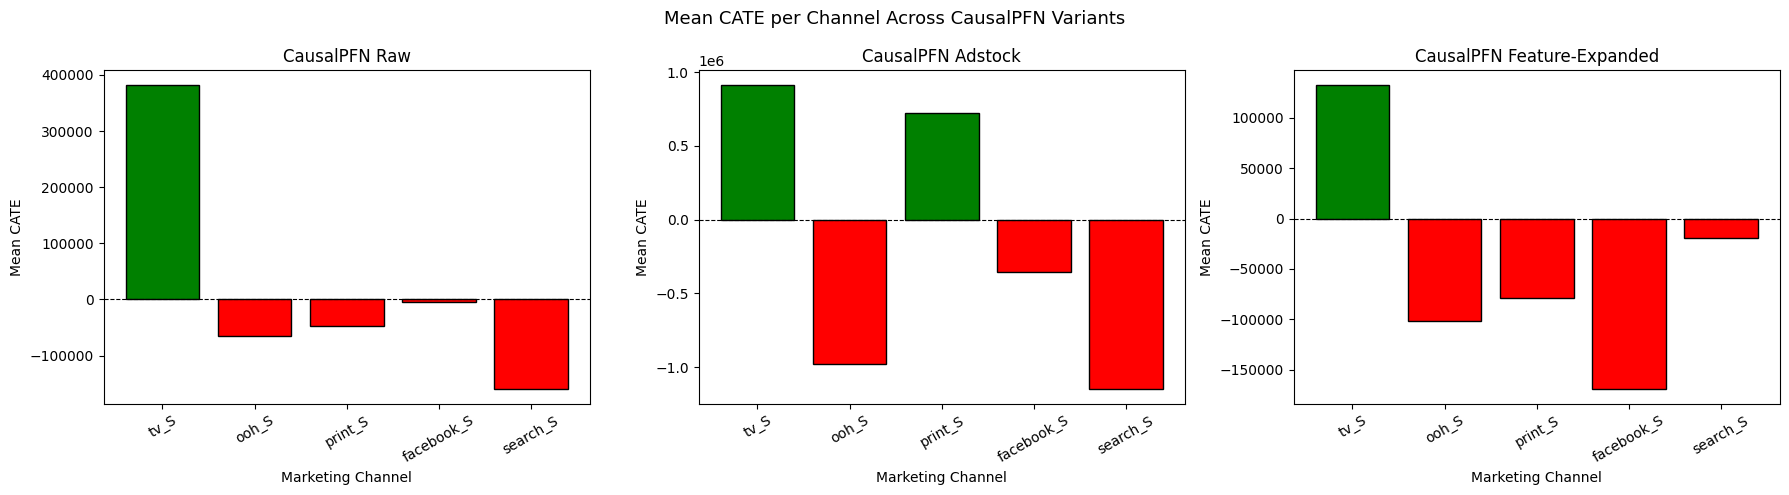

In [20]:
# Visualize mean CATE per channel for all CausalPFN variants
# Green = positive estimated causal effect
# Red = negative estimated causal effect

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variant_results = [
    ("CausalPFN Raw", results_raw),
    ("CausalPFN Adstock", results_ads),
    ("CausalPFN Feature-Expanded", results_features)
]

for ax, (label, results) in zip(axes, variant_results):

    means = [np.mean(results[ch]) for ch in media_cols]

    colors = [
        "green" if v > 0 else "red"
        for v in means
    ]

    ax.bar(
        media_cols,
        means,
        color=colors,
        edgecolor="black"
    )

    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(label)
    ax.set_xlabel("Marketing Channel")
    ax.set_ylabel("Mean CATE")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Mean CATE per Channel Across CausalPFN Variants",
    fontsize=13
)

plt.tight_layout()
plt.show()

### Findings: Mean CATE Summary

The mean CATE values summarize the estimated causal effect of each advertising channel across all test-period observations for the three evaluated CausalPFN specifications.

Channels with positive mean CATE are estimated by the model to causally increase revenue when advertising activity is relatively high. The sign pattern therefore provides a directional comparison with the Bayesian MMM benchmark, which estimates positive contributions for all five marketing channels.

The raw CausalPFN specification recovered a positive attribution direction only for TV advertising, resulting in 20% sign agreement with the Bayesian MMM benchmark.

The adstock-transformed specification improved directional consistency by recovering positive effects for both TV and Print advertising, increasing sign agreement to 40%. This suggests that explicitly incorporating carryover structure can partially improve attribution recovery.

However, the feature-expanded specification, which introduced additional temporal, seasonal, and lagged covariates, did not improve attribution recovery relative to the raw specification. The model again recovered a positive effect only for TV advertising, resulting in 20% sign agreement.

Overall, the results suggest that richer contextual information alone is insufficient for CausalPFN to reliably recover Bayesian MMM attribution patterns. The findings therefore support the broader conclusion that PFN-based causal models may still require stronger structural guidance or more appropriate treatment representations in marketing mix settings.

Importantly, differences in the magnitude of CATE estimates relative to Bayesian MMM channel contributions should not be interpreted as direct model errors, since the two frameworks produce fundamentally different types of attribution outputs.

## 7. Why CausalPFN and Bayesian MMM ROAS Cannot Be Directly Compared

A natural ambition in this comparison is to compute ROAS from CausalPFN outputs
and place them side-by-side with the Bayesian MMM ROAS estimates.
However, this comparison is fundamentally misleading — not because of implementation
differences, but because the two models answer structurally different questions.

### What the Bayesian MMM measures

The Bayesian MMM decomposes total observed revenue into contributions attributed
to each marketing channel over the training period.

ROAS in the Bayesian MMM is defined as:

ROAS_MMM = channel_contribution_total / channel_spend_total

The channel contribution is the model's estimate of how much revenue would not
have been generated if that channel had not spent at all.

This contribution is estimated continuously across all weeks using:
- actual spend intensity,
- adstock carryover,
- and saturation effects.

As a result, the Bayesian MMM produces a continuous spend-response decomposition.

### What CausalPFN measures

CausalPFN instead estimates the Conditional Average Treatment Effect (CATE).

The model estimates the expected revenue difference between treated and untreated observations.

In our feature-expanded specification, treatment was defined as:

T = 1  if spend > median spend  
T = 0  if spend ≤ median spend

This binary treatment setup was used to create a more balanced treatment assignment than the earlier spend > 0 formulation.

The resulting CATE therefore estimates:

"By how much does revenue change in relatively high-spend weeks compared to lower-spend weeks?"

This is fundamentally different from the quantity estimated by the Bayesian MMM.

### Why the two outputs are not directly comparable

#### 1. Continuous vs. binary treatment structure

The Bayesian MMM uses actual continuous spending values.

A week with €500k spend and a week with €5k spend therefore contribute differently
to the estimated channel effect.

CausalPFN instead converts spending into binary treatment states.
The model therefore estimates differences between treatment groups rather than
continuous spend-response relationships.

As a result, dividing CATE estimates by actual spend values does not produce a meaningful ROAS measure.

#### 2. Different temporal aggregation

The Bayesian MMM estimates contributions across the full training period.

The CausalPFN estimates treatment effects using the test-period observations.

Even if both metrics measured similar quantities, they would still reflect
different temporal windows.

#### 3. Different structural assumptions

The Bayesian MMM relies on explicit marketing structure assumptions, including:
- geometric adstock decay,
- logistic saturation,
- and additive revenue decomposition.

CausalPFN instead relies on pretrained causal representations learned from synthetic causal datasets.

Therefore, even when both models identify a positive effect for a channel such as TV,
the underlying causal quantity being estimated is not identical.

### Additional evidence from the feature-expanded specification

An additional feature-expanded CausalPFN specification was evaluated by introducing:
- temporal trend variables,
- seasonal indicators,
- and lagged media covariates.

The purpose was to test whether richer contextual information could improve attribution recovery relative to the Bayesian MMM benchmark.

However, the feature-expanded specification did not improve the overall attribution alignment.

The model still recovered positive attribution only for TV advertising and therefore achieved the same 20% sign agreement as the raw specification.

This finding suggests that the observed limitations are not caused solely by insufficient contextual information.

Instead, the limitations may stem more fundamentally from:
- the binary treatment formulation,
- the absence of explicit marketing structure,
- and the structural differences between PFN-based causal estimation and Bayesian MMM decomposition.

### What can legitimately be compared

| Comparison | Legitimate? | Reason |
|-----------|-------------|--------|
| CATE sign vs. MMM contribution sign | ✓ Yes | Both indicate direction of effect |
| Channel ranking by CATE vs. by ROAS | Partially | Rankings may differ due to binary treatment |
| MMM MAPE vs. CausalPFN predictions | ✗ No | CausalPFN does not generate direct revenue forecasts |
| MMM ROAS magnitude vs. CausalPFN ROAS | ✗ No | The models estimate structurally different quantities |

The appropriate role of CausalPFN in this comparison is therefore not as a direct ROAS competitor to the Bayesian MMM.

Instead, it serves as a complementary causal framework that estimates whether advertising activity causally affects revenue at all — without requiring the explicit marketing assumptions that the Bayesian MMM depends on.

## 8. CausalPFN Summary

CausalPFN was applied to the Robyn simulated weekly dataset to estimate channel-level
Conditional Average Treatment Effects (CATE) as an alternative to the Bayesian MMM's
channel contribution analysis.

Three different CausalPFN specifications were evaluated:

- **CausalPFN Raw:** binary treatment on raw media spend
- **CausalPFN Adstock:** geometric adstock preprocessing using Bayesian MMM posterior mean alpha values
- **CausalPFN Feature-Expanded:** additional temporal, seasonal, and lagged covariates

For each channel, the model was fitted on the training period and CATE estimates
were generated for all 42 test-period observations.

### Key Results

| Channel | Bayesian MMM ROAS | CausalPFN Raw Mean CATE | CausalPFN Adstock Mean CATE | CausalPFN Feature-Expanded Mean CATE |
|---------|------------------|--------------------------|------------------------------|--------------------------------------|
| tv_S | 0.261 | +381,131 | +908,743 | +132,138 |
| ooh_S | 0.105 | −65,831 | −981,255 | −101,743 |
| print_S | 0.080 | −46,366 | +725,554 | −78,869 |
| facebook_S | 0.126 | −3,943 | −354,231 | −168,923 |
| search_S | 0.048 | −158,679 | −1,145,778 | −19,594 |

### Sign Agreement with Bayesian MMM

| Model | Channels with correct sign | Agreement rate |
|-------|----------------------------|----------------|
| CausalPFN Raw | tv_S only | 20% |
| CausalPFN Adstock | tv_S, print_S | 40% |
| CausalPFN Feature-Expanded | tv_S only | 20% |
| Bayesian MMM | all | 100% (reference) |

### Interpretation

The sign agreement results show that the raw CausalPFN specification recovered the positive attribution direction only for TV advertising.

Introducing adstock preprocessing partially improved attribution recovery by additionally recovering a positive effect for Print advertising, increasing sign agreement from 20% to 40%.

However, the feature-expanded specification did not improve attribution alignment relative to the simpler variants.

Even after introducing:
- temporal trend variables,
- seasonal indicators,
- and lagged media covariates,

the model still recovered positive attribution only for TV advertising and therefore returned to 20% sign agreement.

This finding suggests that richer contextual information alone is insufficient for CausalPFN to reliably recover Bayesian MMM attribution patterns.

The results therefore indicate that the primary limitation may not simply be missing observable context, but rather:
- the binary treatment formulation,
- observational confounding,
- and the absence of explicit marketing structure assumptions.

In observational marketing data, high advertising spend often coincides with naturally strong revenue periods.
Without experimental variation, disentangling true causal lift from contextual confounding becomes difficult.

CausalPFN may therefore partially capture:
- seasonal activation patterns,
- correlated marketing behavior,
- or contextual associations,

rather than recovering the same contribution decomposition estimated by the Bayesian MMM.

### Critical Limitation

The ROAS magnitudes of CausalPFN and the Bayesian MMM are not directly comparable.

The Bayesian MMM estimates continuous channel contributions using:
- actual spend intensity,
- adstock carryover,
- and saturation transformations.

CausalPFN instead estimates binary-treatment causal effects based on treatment-group differences.

As a result, the two frameworks estimate fundamentally different causal quantities.

The appropriate role of CausalPFN in this comparison is therefore not as a direct ROAS estimation framework, but rather as a directional causal benchmark that evaluates whether advertising activity is estimated to positively affect revenue at all.

In this experiment, CausalPFN achieved only limited directional agreement with the Bayesian MMM benchmark, suggesting that binary treatment formulation and observational confounding remain major challenges for PFN-based causal estimation in Marketing Mix Modeling settings.